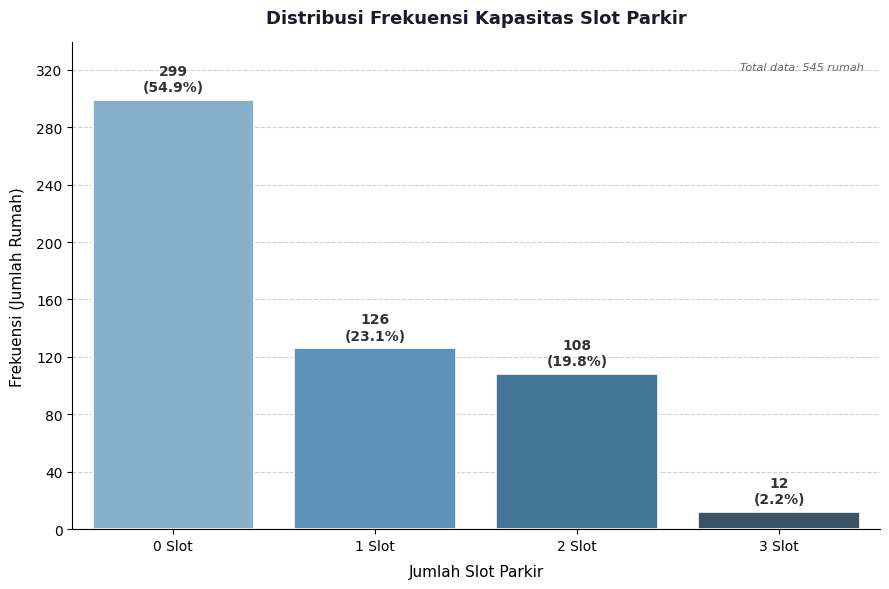

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

"""Tampilkan grafik sebaran distribusi dari frekuensi jumlah slot kapasitas parkir (parking). Tampilkan dalam Histogram / Countplot"""
# ─────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────
df = pd.read_csv('Kelas C_Housing.csv')  # sesuaikan path jika perlu
 
# Hitung frekuensi tiap nilai parkir untuk anotasi
parking_counts = df['parking'].value_counts().sort_index()
total = len(df)
 
# ─────────────────────────────────────────
# SETUP FIGURE — pendekatan objek (axes)
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 1, figsize=(9, 6))
ax = axes  # ganti ke axes[baris, kolom] saat digabung ke grid multi-panel
 
# ─────────────────────────────────────────
# PLOT: COUNTPLOT DISTRIBUSI PARKIR
# ─────────────────────────────────────────
palette = sns.color_palette("Blues_d", n_colors=df['parking'].nunique())
 
sns.countplot(
    data      = df,
    x         = 'parking',
    hue       = 'parking',
    palette   = palette,
    legend    = False,
    edgecolor = 'white',
    linewidth = 1.2,
    ax        = ax
)
 
# Anotasi jumlah + persentase di atas setiap bar
for bar, (slot, count) in zip(ax.patches, parking_counts.items()):
    pct = count / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 4,
        f'{count}\n({pct:.1f}%)',
        ha         = 'center',
        va         = 'bottom',
        fontsize   = 10,
        fontweight = 'bold',
        color      = '#333333'
    )
 
# ─────────────────────────────────────────
# LABELING & STYLING
# ─────────────────────────────────────────
ax.set_title(
    'Distribusi Frekuensi Kapasitas Slot Parkir',
    fontsize=13, fontweight='bold', pad=14, color='#1a1a2e'
)
ax.set_xlabel('Jumlah Slot Parkir', fontsize=11, labelpad=8)
ax.set_ylabel('Frekuensi (Jumlah Rumah)', fontsize=11, labelpad=8)
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['0 Slot', '1 Slot', '2 Slot', '3 Slot'], fontsize=10)
ax.set_ylim(0, parking_counts.max() + 40)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
 
# Info tambahan
ax.text(
    0.98, 0.96,
    f'Total data: {total} rumah',
    transform=ax.transAxes, fontsize=8,
    color='#666666', ha='right', va='top', style='italic'
)
 
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('kategori_d_distribusi_parkir.png', dpi=150, bbox_inches='tight')
plt.show()